In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing   import LabelEncoder

print("All imports OK")

All imports OK


In [2]:
# ── ONLY EDIT THESE ───────────────────────────────────────────────
CSV_PATH    = "../datasets 2/landmarks.csv"
MODELS_DIR  = "../models"
OUTPUTS_DIR = "../outputs"
# ──────────────────────────────────────────────────────────────────

RF_PATH  = os.path.join(MODELS_DIR, "rf_model.pkl")
MLP_PATH = os.path.join(MODELS_DIR, "mlp_model.pkl")
LE_PATH  = os.path.join(MODELS_DIR, "label_encoder.pkl")

for path in [CSV_PATH, RF_PATH, MLP_PATH, LE_PATH]:
    assert os.path.isfile(path), f"❌ Not found: {path}\n   Run notebooks 02 and 03 first!"

os.makedirs(OUTPUTS_DIR, exist_ok=True)
print("✅ All files found")

✅ All files found


In [3]:
# Load CSV
df    = pd.read_csv(CSV_PATH)
X     = df.drop(columns=['label']).values.astype(np.float32)
y_raw = df['label'].values

# Load label encoder
with open(LE_PATH,  'rb') as f: le  = pickle.load(f)
with open(RF_PATH,  'rb') as f: rf  = pickle.load(f)
with open(MLP_PATH, 'rb') as f: mlp = pickle.load(f)

y = le.transform(y_raw)

# Recreate the EXACT same split as notebook 03 (same random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Get predictions
rf_preds  = rf.predict(X_test)
mlp_preds = mlp.predict(X_test)

print(f"✅ Loaded {len(X):,} samples  |  {len(le.classes_)} classes")
print(f"   Test set size : {len(X_test):,} samples")
print(f"   Classes       : {list(le.classes_)}")

✅ Loaded 5,304 samples  |  32 classes
   Test set size : 1,061 samples
   Classes       : ['ain', 'al', 'aleff', 'bb', 'dal', 'dha', 'dhad', 'fa', 'gaaf', 'ghain', 'ha', 'haa', 'jeem', 'kaaf', 'khaa', 'la', 'laam', 'meem', 'nun', 'ra', 'saad', 'seen', 'sheen', 'ta', 'taa', 'thaa', 'thal', 'toot', 'waw', 'ya', 'yaa', 'zay']


            EVALUATION RESULTS
             Model Accuracy Precision Recall F1 Score
     Random Forest   71.44%    70.56% 71.44%   70.46%
MLP Neural Network   78.04%    79.10% 78.04%   78.12%


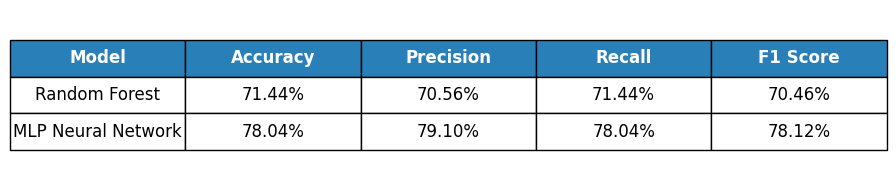

✅ Saved to outputs/metrics_table.png


In [4]:
def get_metrics(y_true, y_pred, name):
    return {
        'Model'    : name,
        'Accuracy' : f"{accuracy_score(y_true, y_pred)*100:.2f}%",
        'Precision': f"{precision_score(y_true, y_pred, average='weighted', zero_division=0)*100:.2f}%",
        'Recall'   : f"{recall_score(y_true, y_pred, average='weighted', zero_division=0)*100:.2f}%",
        'F1 Score' : f"{f1_score(y_true, y_pred, average='weighted', zero_division=0)*100:.2f}%",
    }

results = pd.DataFrame([
    get_metrics(y_test, rf_preds,  "Random Forest"),
    get_metrics(y_test, mlp_preds, "MLP Neural Network"),
])

print("=" * 60)
print("            EVALUATION RESULTS")
print("=" * 60)
print(results.to_string(index=False))
print("=" * 60)

# Save as image for poster
fig, ax = plt.subplots(figsize=(9, 2))
ax.axis('off')
table = ax.table(
    cellText=results.values,
    colLabels=results.columns,
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2)

# Color header row
for j in range(len(results.columns)):
    table[0, j].set_facecolor('#2980b9')
    table[0, j].set_text_props(color='white', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/metrics_table.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to outputs/metrics_table.png")

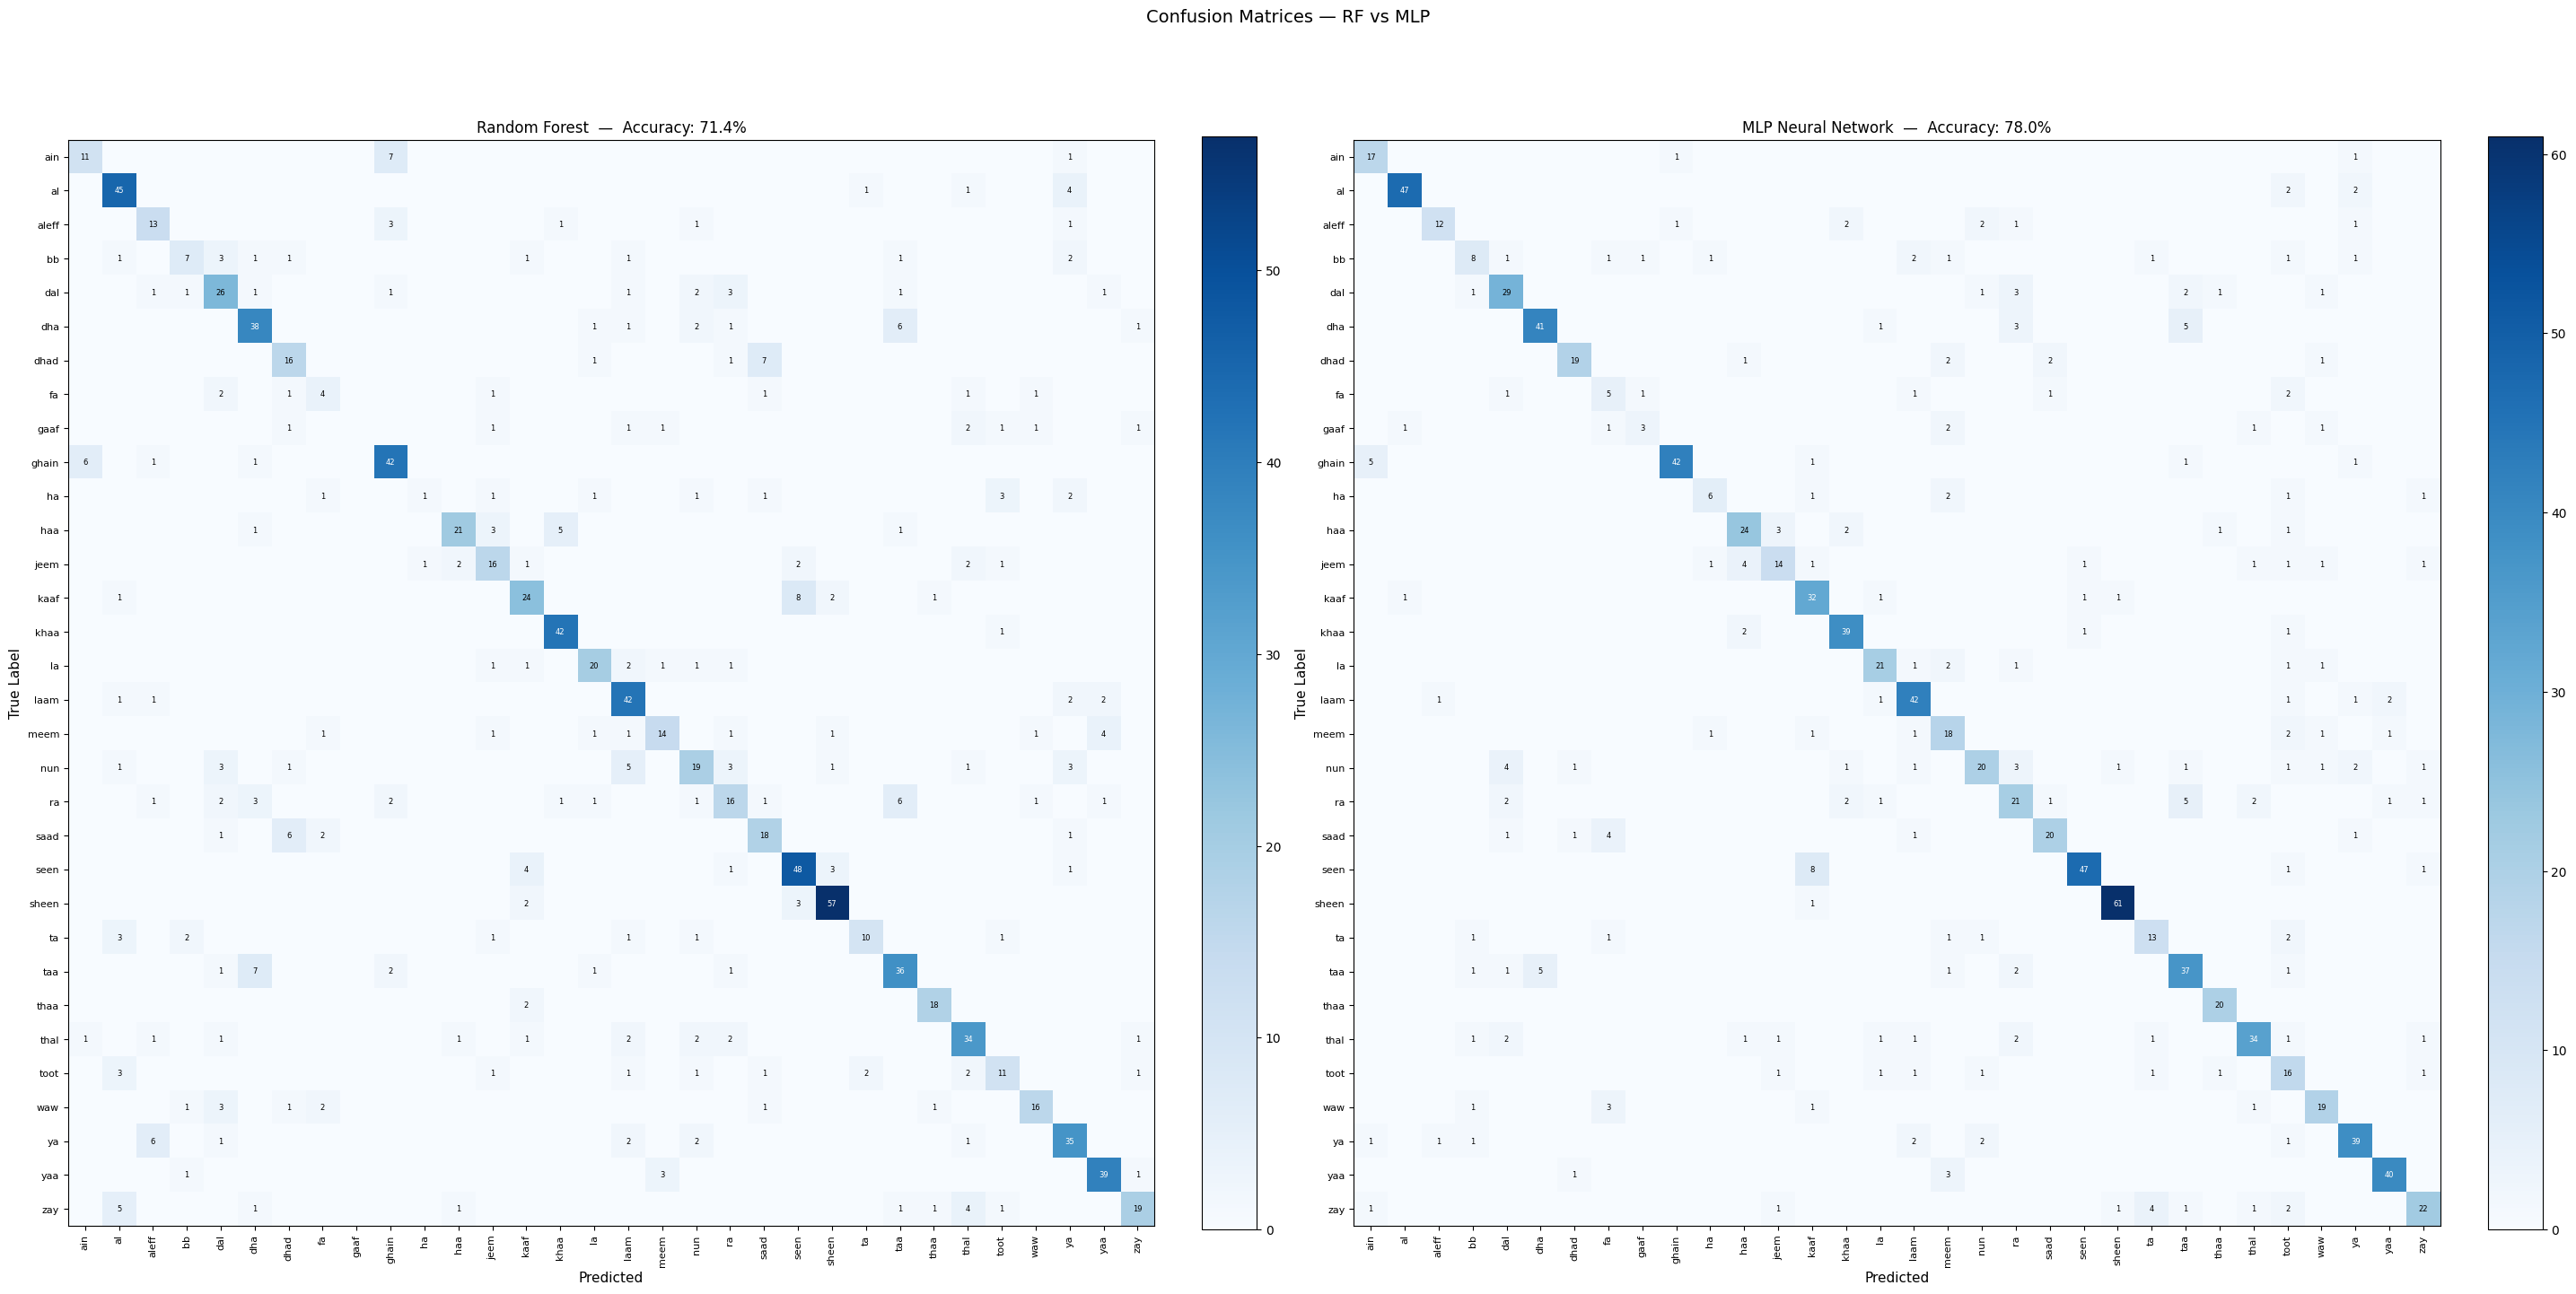

✅ Saved to outputs/confusion_matrices.png


In [5]:
n       = len(le.classes_)
figsize = max(14, n * 0.45)

fig, axes = plt.subplots(1, 2, figsize=(figsize * 2, figsize))

for ax, preds, title in zip(axes,
                             [rf_preds,       mlp_preds],
                             ['Random Forest', 'MLP Neural Network']):
    cm  = confusion_matrix(y_test, preds)
    acc = accuracy_score(y_test, preds)

    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(le.classes_, rotation=90, fontsize=8)
    ax.set_yticklabels(le.classes_, fontsize=8)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title(f'{title}  —  Accuracy: {acc*100:.1f}%', fontsize=12)

    # Write counts inside cells
    thresh = cm.max() / 2
    for i in range(n):
        for j in range(n):
            if cm[i, j] > 0:
                ax.text(j, i, str(cm[i, j]),
                        ha='center', va='center', fontsize=6,
                        color='white' if cm[i, j] > thresh else 'black')

plt.suptitle('Confusion Matrices — RF vs MLP', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/confusion_matrices.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved to outputs/confusion_matrices.png")

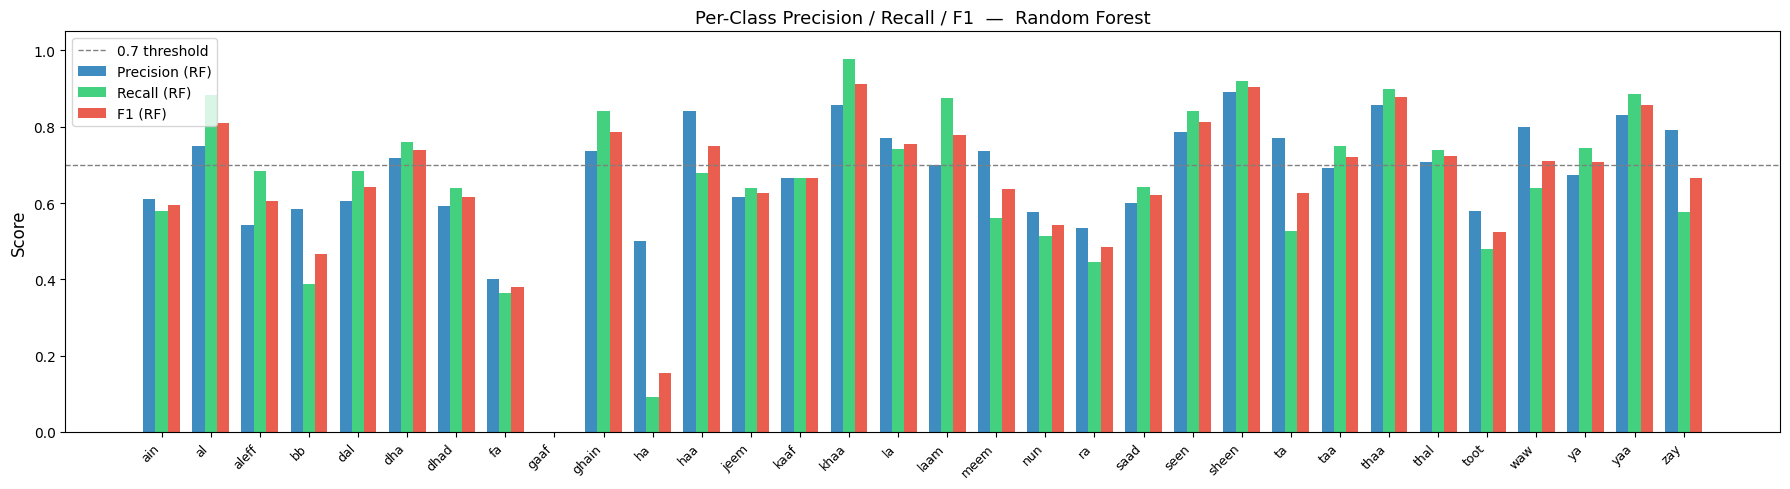

✅ Saved to outputs/per_class_metrics.png


In [6]:
report_rf  = classification_report(y_test, rf_preds,
                                    target_names=le.classes_,
                                    output_dict=True, zero_division=0)
report_mlp = classification_report(y_test, mlp_preds,
                                    target_names=le.classes_,
                                    output_dict=True, zero_division=0)

classes = list(le.classes_)
rf_f1   = [report_rf[c]['f1-score']  for c in classes]
mlp_f1  = [report_mlp[c]['f1-score'] for c in classes]
prec    = [report_rf[c]['precision'] for c in classes]
rec     = [report_rf[c]['recall']    for c in classes]

x     = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(x - width, prec,   width, label='Precision (RF)', color='#2980b9', alpha=0.9)
ax.bar(x,         rec,    width, label='Recall (RF)',    color='#2ecc71', alpha=0.9)
ax.bar(x + width, rf_f1,  width, label='F1 (RF)',        color='#e74c3c', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('Per-Class Precision / Recall / F1  —  Random Forest', fontsize=13)
ax.axhline(0.7, color='gray', linestyle='--', linewidth=1, label='0.7 threshold')
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/per_class_metrics.png", dpi=150)
plt.show()
print("✅ Saved to outputs/per_class_metrics.png")

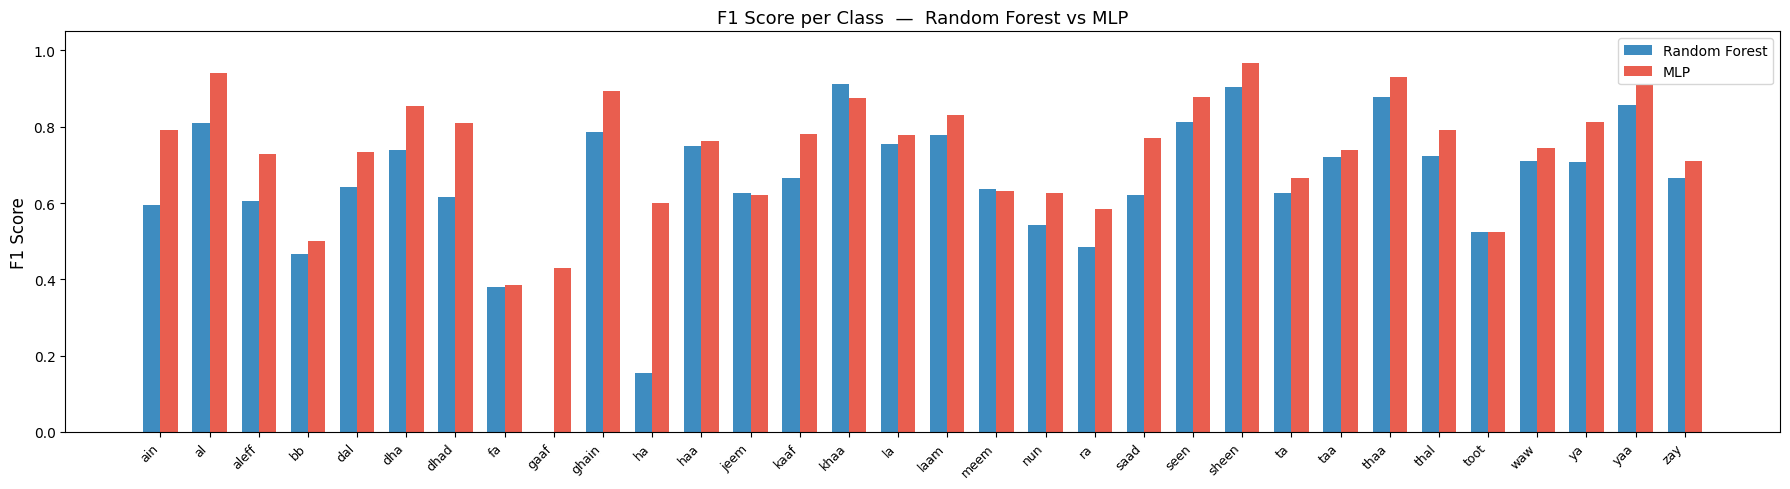

✅ Saved to outputs/rf_vs_mlp_f1.png


In [7]:
x     = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(x - width/2, rf_f1,  width, label='Random Forest', color='#2980b9', alpha=0.9)
ax.bar(x + width/2, mlp_f1, width, label='MLP',           color='#e74c3c', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('F1 Score per Class  —  Random Forest vs MLP', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/rf_vs_mlp_f1.png", dpi=150)
plt.show()
print("✅ Saved to outputs/rf_vs_mlp_f1.png")

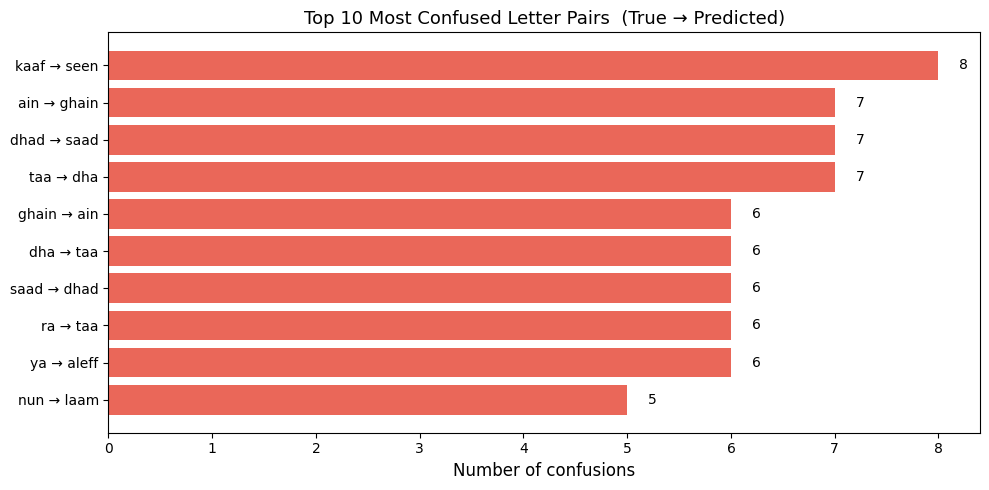

✅ Saved to outputs/confused_pairs.png

Insight: These pairs are visually similar signs — expected to confuse the model.


In [8]:
# Find which letters the model confuses most with each other
errors_true = y_test[rf_preds != y_test]
errors_pred = rf_preds[rf_preds != y_test]

confused_pairs = Counter(zip(
    [le.classes_[i] for i in errors_true],
    [le.classes_[i] for i in errors_pred]
))

top10 = confused_pairs.most_common(10)
pair_labels = [f"{t} → {p}" for (t, p), _ in top10]
pair_counts = [c for _, c in top10]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(pair_labels[::-1], pair_counts[::-1], color='#e74c3c', alpha=0.85)
ax.set_xlabel('Number of confusions', fontsize=12)
ax.set_title('Top 10 Most Confused Letter Pairs  (True → Predicted)', fontsize=13)

for bar, count in zip(bars, pair_counts[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/confused_pairs.png", dpi=150)
plt.show()
print("✅ Saved to outputs/confused_pairs.png")
print("\nInsight: These pairs are visually similar signs — expected to confuse the model.")

Running 5-fold cross-validation on Random Forest...
(takes 2-4 minutes)

CV Scores per fold : ['70.8%', '67.5%', '69.7%', '64.6%', '64.9%']
Mean accuracy      : 67.50%
Std deviation      : 2.50%


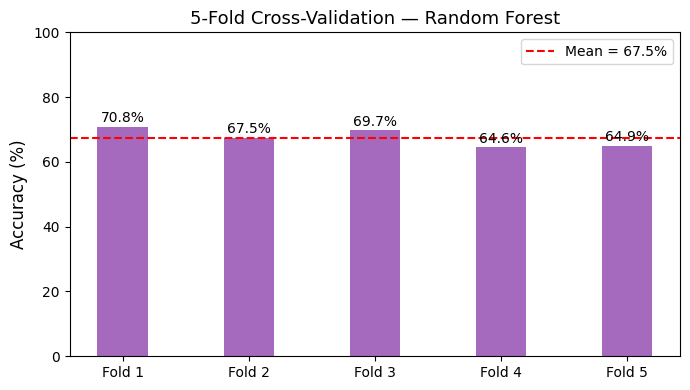

✅ Saved to outputs/cross_validation.png


In [9]:
print("Running 5-fold cross-validation on Random Forest...")
print("(takes 2-4 minutes)\n")

cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy', n_jobs=-1)

print(f"CV Scores per fold : {[f'{s*100:.1f}%' for s in cv_scores]}")
print(f"Mean accuracy      : {cv_scores.mean()*100:.2f}%")
print(f"Std deviation      : {cv_scores.std()*100:.2f}%")

# Chart
fig, ax = plt.subplots(figsize=(7, 4))
folds = [f'Fold {i+1}' for i in range(len(cv_scores))]
bars  = ax.bar(folds, cv_scores * 100, color='#9b59b6', width=0.4, alpha=0.9)
ax.axhline(cv_scores.mean()*100, color='red', linestyle='--',
           linewidth=1.5, label=f'Mean = {cv_scores.mean()*100:.1f}%')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.set_title('5-Fold Cross-Validation — Random Forest', fontsize=13)
ax.legend()

for bar, score in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{score*100:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/cross_validation.png", dpi=150)
plt.show()
print("✅ Saved to outputs/cross_validation.png")

In [10]:
print("=" * 55)
print("         NOTEBOOK 04 COMPLETE")
print("=" * 55)
print(f"\n  RF  Accuracy : {accuracy_score(y_test, rf_preds)*100:.2f}%")
print(f"  MLP Accuracy : {accuracy_score(y_test, mlp_preds)*100:.2f}%")
print(f"\n  Charts saved to outputs/ :")
charts = [
    "metrics_table.png       ← put this on your poster",
    "confusion_matrices.png  ← put this on your poster",
    "per_class_metrics.png   ← put this on your poster",
    "rf_vs_mlp_f1.png        ← good for presentation slides",
    "confused_pairs.png      ← great talking point",
    "cross_validation.png    ← proves model generalizes well",
]
for c in charts:
    print(f"    📊 {c}")
print("=" * 55)
print("\nNext → app.py : Build the live webcam GUI")

         NOTEBOOK 04 COMPLETE

  RF  Accuracy : 71.44%
  MLP Accuracy : 78.04%

  Charts saved to outputs/ :
    📊 metrics_table.png       ← put this on your poster
    📊 confusion_matrices.png  ← put this on your poster
    📊 per_class_metrics.png   ← put this on your poster
    📊 rf_vs_mlp_f1.png        ← good for presentation slides
    📊 confused_pairs.png      ← great talking point
    📊 cross_validation.png    ← proves model generalizes well

Next → app.py : Build the live webcam GUI
